In [27]:
# 1. Imports y rutas
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "tables" / "chapter5"
FIGURES_DIR = PROJECT_ROOT / "figures" / "chapter5"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [28]:
# 2. Cargar data/processed/dataset_cap4_regimes_full.csv en df_full
path = PROCESSED_DATA_DIR / "dataset_cap4_regimes_full.csv"
df_full = pd.read_csv(path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print("df_full shape:", df_full.shape)


df_full shape: (6631, 6)


In [29]:
# 3. Validar columnas date, sample_split_main, ret_1d, regime
required_cols = ["date", "sample_split_main", "ret_1d", "regime"]
missing_cols = [c for c in required_cols if c not in df_full.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas obligatorias en df_full: {missing_cols}")


In [30]:
# 4. Validar que df_full contiene train y test
splits_presentes = set(df_full["sample_split_main"].dropna().unique())
required_splits = {"train", "test"}
if not required_splits.issubset(splits_presentes):
    raise ValueError(
        f"sample_split_main no contiene ambos splits requeridos. Presentes: {sorted(splits_presentes)}"
    )


In [31]:
# 5. Crear df_test filtrando sample_split_main == "test"
df_test = df_full[df_full["sample_split_main"] == "test"].copy()
df_test = df_test.sort_values("date").reset_index(drop=True)

print("df_test shape:", df_test.shape)


df_test shape: (1357, 6)


In [32]:
# 6. Validar que df_test no está vacío
if df_test.empty:
    raise ValueError("df_test está vacío tras filtrar sample_split_main == 'test'.")


In [33]:
# 7. Cargar mapping de exposición por régimen desde Chapter 4
mapping_path = PROJECT_ROOT / "tables" / "chapter4" / "regime_exposure_mapping.csv"
regime_mapping = pd.read_csv(mapping_path)

required_map_cols = ["regime", "economic_label", "risk_order", "target_exposure"]
missing_map_cols = [c for c in required_map_cols if c not in regime_mapping.columns]
if missing_map_cols:
    raise ValueError(f"Faltan columnas en regime_exposure_mapping.csv: {missing_map_cols}")

if regime_mapping["regime"].duplicated().any():
    dups = sorted(regime_mapping.loc[regime_mapping["regime"].duplicated(), "regime"].unique())
    raise ValueError(f"Hay regímenes duplicados en el mapping: {dups}")

regime_exposure_map = dict(zip(regime_mapping["regime"], regime_mapping["target_exposure"]))

print("Cargado mapping:", mapping_path)
display(regime_mapping.sort_values("risk_order"))


Cargado mapping: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter4/regime_exposure_mapping.csv


,regime,economic_label,risk_order,target_exposure
0,0,low_risk,1,1.00
1,2,medium_risk,2,0.75
2,1,high_risk,3,0.25


In [34]:
# 8. Crear target_exposure con map
# 9. Validar cobertura completa y ausencia de nulos en target_exposure
regimes_test = set(df_test["regime"].dropna().unique())
regimes_mapped = set(regime_mapping["regime"].dropna().unique())

missing_regimes = sorted(regimes_test - regimes_mapped)
if missing_regimes:
    raise ValueError(f"Regímenes en df_test sin mapping en CSV: {missing_regimes}")

df_test["target_exposure"] = df_test["regime"].map(regime_exposure_map)

if df_test["target_exposure"].isna().any():
    faltantes = sorted(df_test.loc[df_test["target_exposure"].isna(), "regime"].dropna().unique())
    raise ValueError(f"Hay target_exposure nulo; regímenes implicados: {faltantes}")


In [35]:
# 10. Crear strategy_exposure = target_exposure.shift(1)
# 11. Crear df_test_bt eliminando strategy_exposure nulo
# 12. Validar que df_test_bt no está vacío
df_test["strategy_exposure"] = df_test["target_exposure"].shift(1)
df_test_bt = df_test.dropna(subset=["strategy_exposure"]).copy()

print("df_test_bt shape:", df_test_bt.shape)

if df_test_bt.empty:
    raise ValueError("df_test_bt está vacío tras eliminar strategy_exposure nulo.")


df_test_bt shape: (1356, 8)


In [36]:
# 13. Calcular benchmark_return, strategy_return, benchmark_cum y strategy_cum
df_test_bt["benchmark_return"] = df_test_bt["ret_1d"]
df_test_bt["strategy_return"] = df_test_bt["strategy_exposure"] * df_test_bt["ret_1d"]

df_test_bt["benchmark_cum"] = np.exp(df_test_bt["benchmark_return"].cumsum())
df_test_bt["strategy_cum"] = np.exp(df_test_bt["strategy_return"].cumsum())


In [37]:
# 14. Calcular metrics_test con total_return, mean_daily_return, daily_volatility, VaR_95, CVaR_95 y max_drawdown
def compute_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    return cumulative_returns / running_max - 1


def historical_var(returns, alpha=0.95):
    return returns.quantile(1 - alpha)


def historical_cvar(returns, alpha=0.95):
    var = historical_var(returns, alpha)
    return returns[returns <= var].mean()


benchmark_drawdown = compute_drawdown(df_test_bt["benchmark_cum"])
strategy_drawdown = compute_drawdown(df_test_bt["strategy_cum"])

metrics_test = pd.DataFrame(
    {
        "strategy": ["Buy & Hold", "Regime-based"],
        "total_return": [
            df_test_bt["benchmark_cum"].iloc[-1] - 1,
            df_test_bt["strategy_cum"].iloc[-1] - 1,
        ],
        "mean_daily_return": [
            df_test_bt["benchmark_return"].mean(),
            df_test_bt["strategy_return"].mean(),
        ],
        "daily_volatility": [
            df_test_bt["benchmark_return"].std(),
            df_test_bt["strategy_return"].std(),
        ],
        "VaR_95": [
            historical_var(df_test_bt["benchmark_return"]),
            historical_var(df_test_bt["strategy_return"]),
        ],
        "CVaR_95": [
            historical_cvar(df_test_bt["benchmark_return"]),
            historical_cvar(df_test_bt["strategy_return"]),
        ],
        "max_drawdown": [
            benchmark_drawdown.min(),
            strategy_drawdown.min(),
        ],
    }
)

metrics_test


,strategy,total_return,mean_daily_return,daily_volatility,VaR_95,CVaR_95,max_drawdown
0,Buy & Hold,1.208354,0.000584,0.010256,-0.015875,-0.023772,-0.217647
1,Regime-based,0.895205,0.000471,0.008695,-0.014089,-0.020212,-0.232797


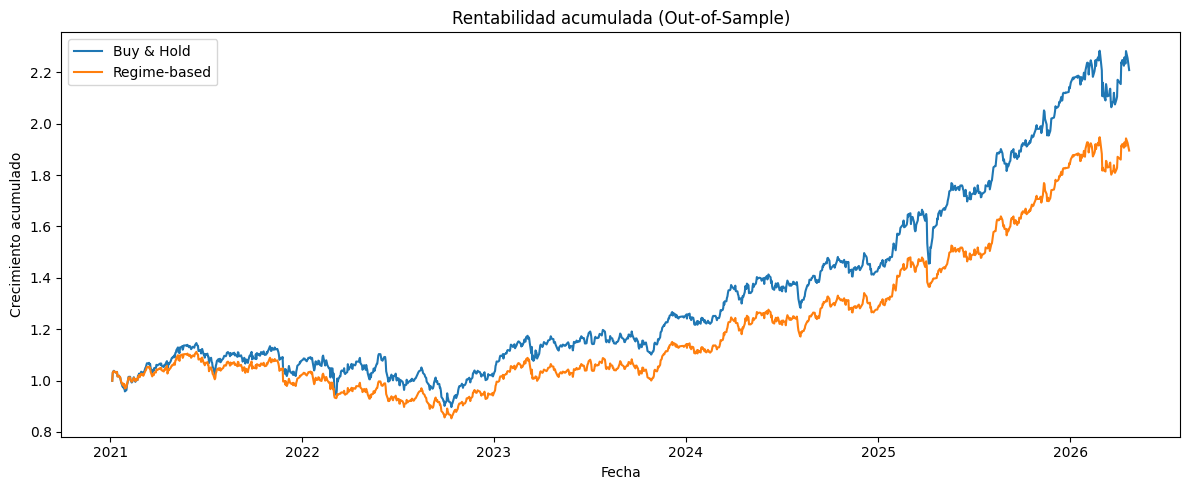

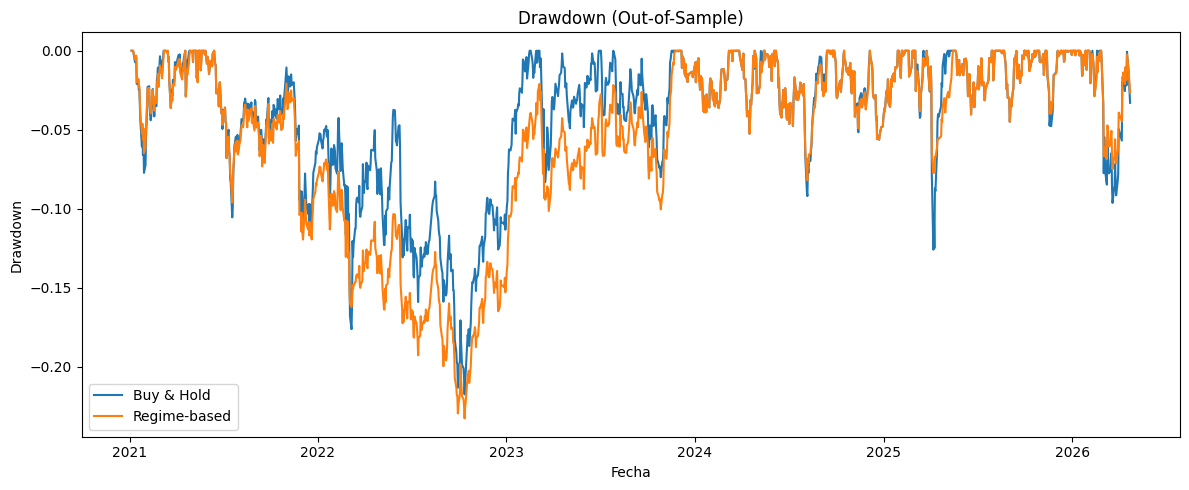

In [38]:
# 15. Generar gráficos OOS de acumulado y drawdown
plt.figure(figsize=(12, 5))
plt.plot(df_test_bt["date"], df_test_bt["benchmark_cum"], label="Buy & Hold")
plt.plot(df_test_bt["date"], df_test_bt["strategy_cum"], label="Regime-based")
plt.title("Rentabilidad acumulada (Out-of-Sample)")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento acumulado")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_test_bt["date"], benchmark_drawdown, label="Buy & Hold")
plt.plot(df_test_bt["date"], strategy_drawdown, label="Regime-based")
plt.title("Drawdown (Out-of-Sample)")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
# 16. Exportar:
#     data/processed/backtest_oos_results.csv
#     tables/chapter5/oos_performance_metrics.csv
df_test_bt.to_csv(PROCESSED_DATA_DIR / "backtest_oos_results.csv", index=False)
metrics_test.to_csv(TABLES_DIR / "oos_performance_metrics.csv", index=False)

print("Exportado:", PROCESSED_DATA_DIR / "backtest_oos_results.csv")
print("Exportado:", TABLES_DIR / "oos_performance_metrics.csv")


Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/data/processed/backtest_oos_results.csv
Exportado: /home/apalo/projects/TMF-Market-Regimes-Risk-Portfolio/tables/chapter5/oos_performance_metrics.csv
